In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
%matplotlib inline

DATA_PATH = "../data/raw/diabetes_012_health_indicators_BRFSS2015.csv"
df = pd.read_csv(DATA_PATH)

# Make target easier to read in plots
df["Diabetes_label"] = df["Diabetes_012"].map({
    0.0: "No diabetes",
    1.0: "Prediabetes",
    2.0: "Diabetes"
})

print(df.shape)
df.head()

(253680, 23)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_label
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0,No diabetes
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0,No diabetes
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0,No diabetes
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0,No diabetes
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0,No diabetes


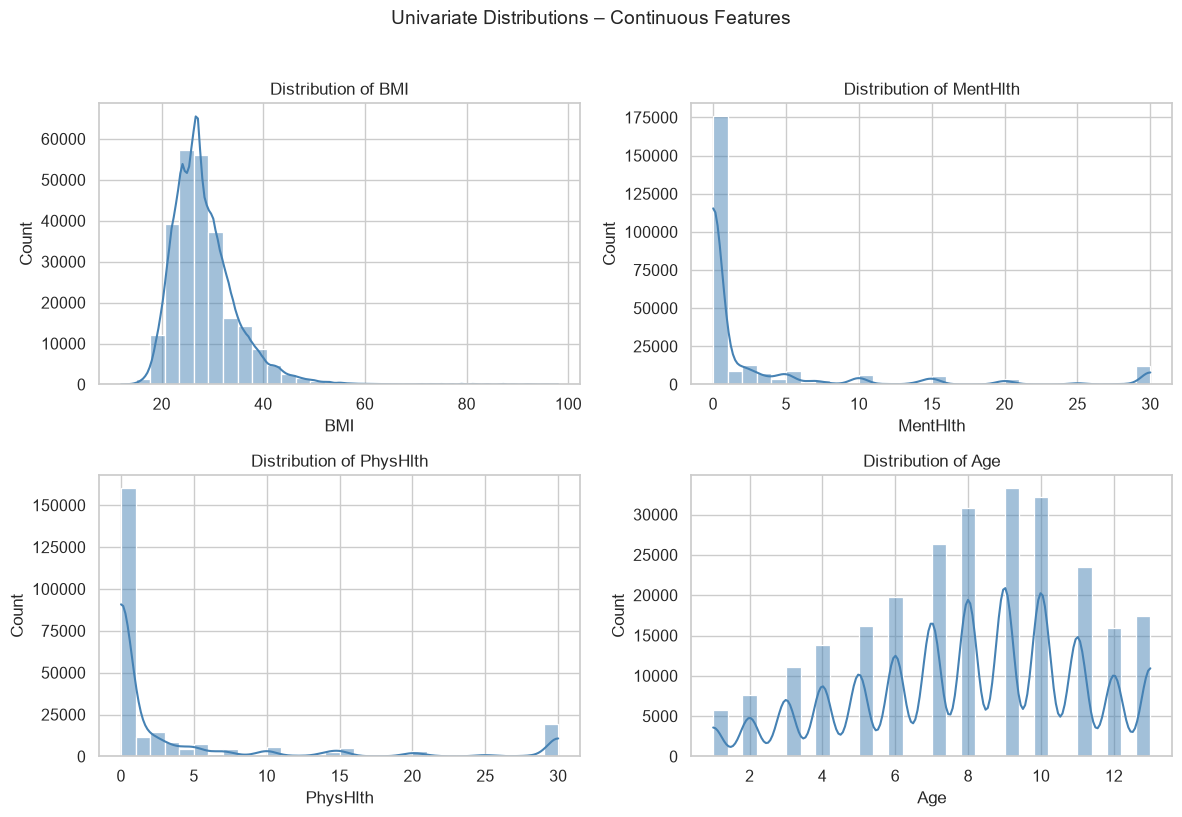

In [2]:
continuous = ["BMI", "MentHlth", "PhysHlth", "Age"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, col in zip(axes, continuous):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)

plt.suptitle("Univariate Distributions – Continuous Features", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

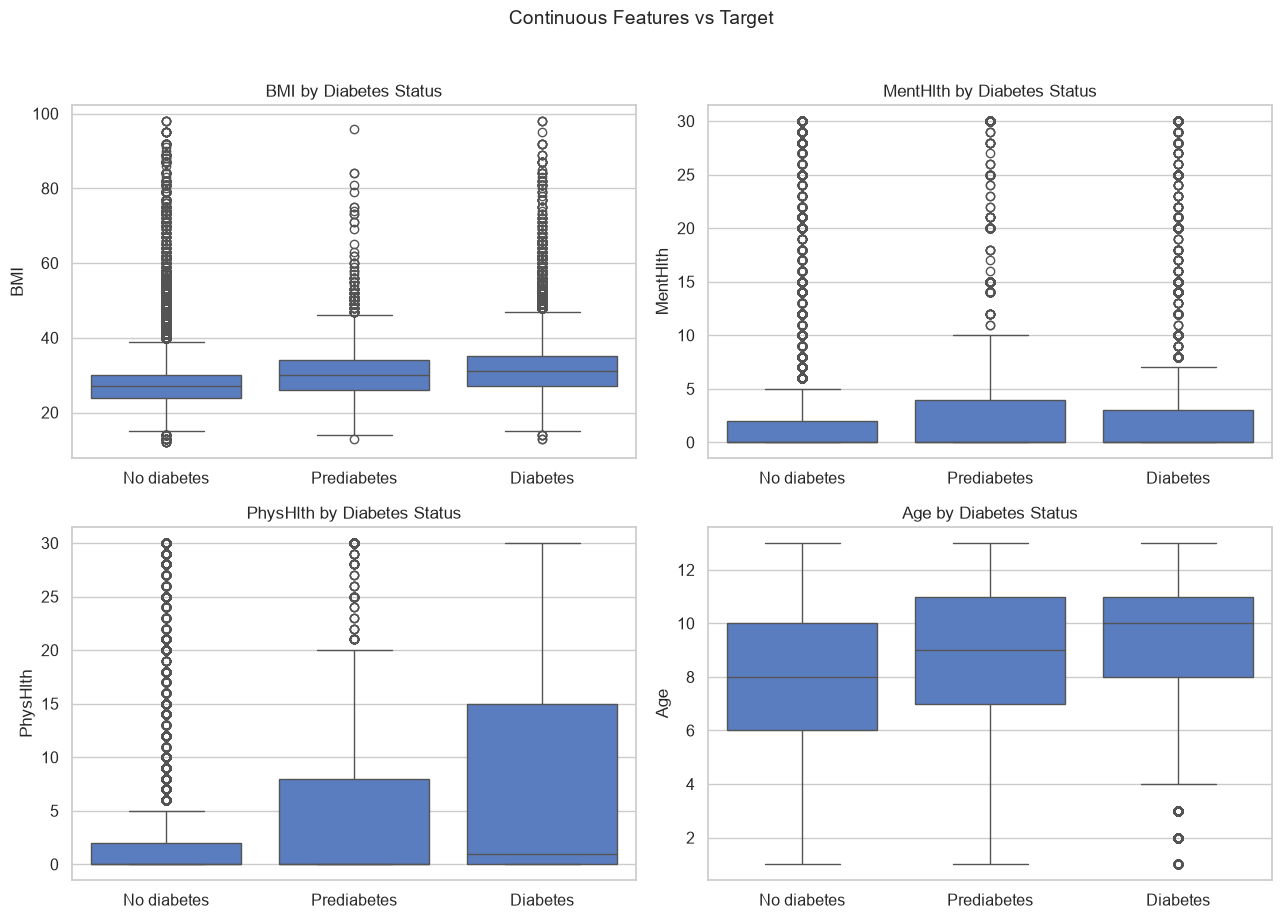

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

for ax, col in zip(axes, continuous):
    sns.boxplot(data=df, x="Diabetes_label", y=col, ax=ax, 
                order=["No diabetes", "Prediabetes", "Diabetes"])
    ax.set_title(f"{col} by Diabetes Status")
    ax.set_xlabel("")

plt.suptitle("Continuous Features vs Target", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

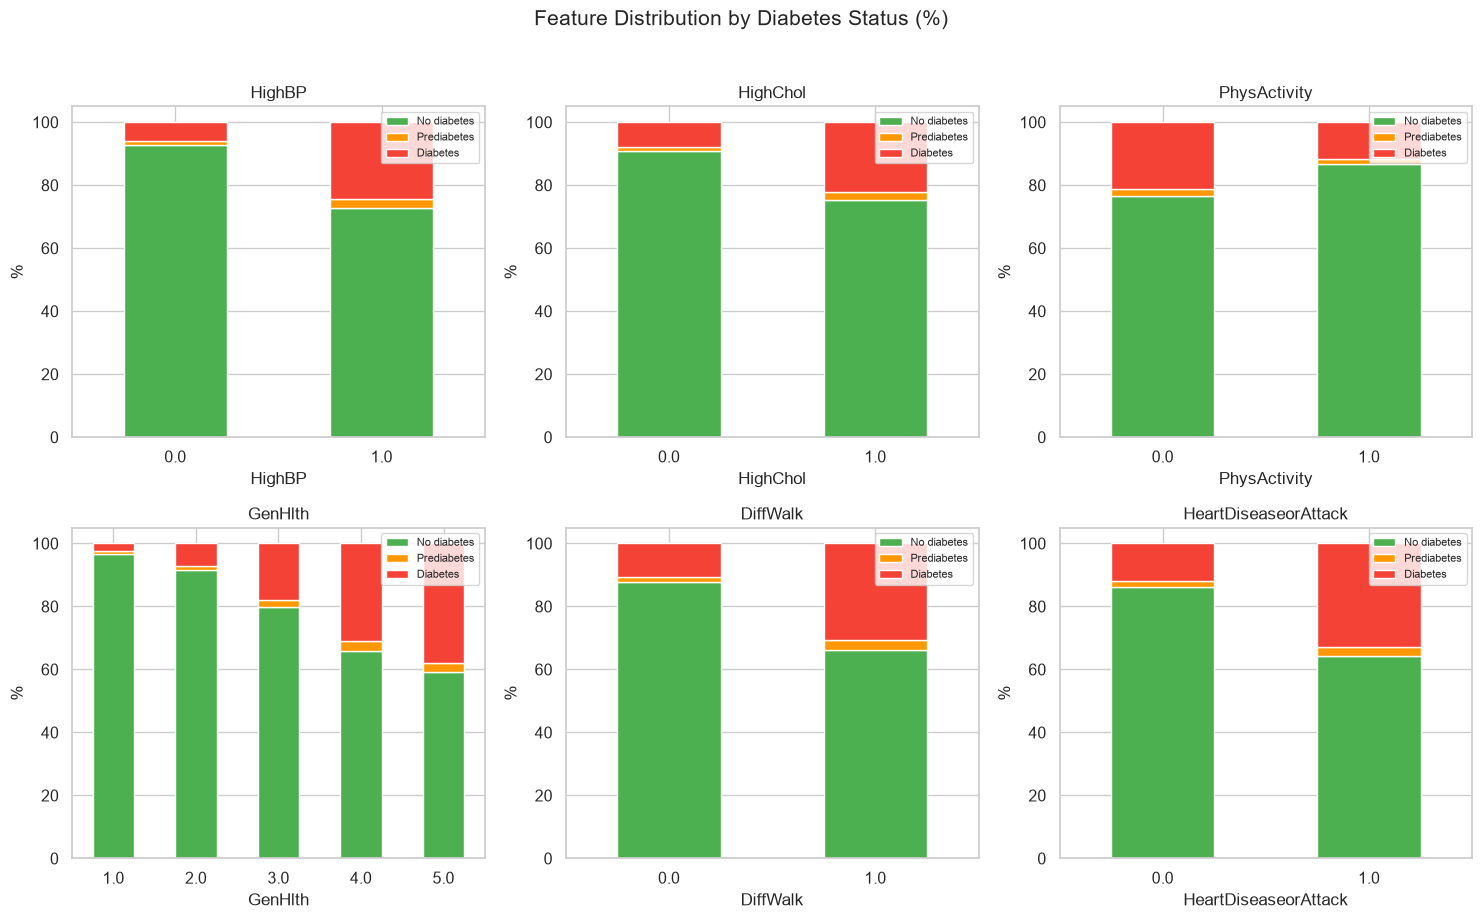

In [4]:
binary_or_ordinal = [
    "HighBP", "HighChol", "Smoker", "Stroke", "HeartDiseaseorAttack",
    "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump",
    "DiffWalk", "Sex", "GenHlth", "Education", "Income"
]

# Quick stacked % view for a few important ones
important = ["HighBP", "HighChol", "PhysActivity", "GenHlth", "DiffWalk", "HeartDiseaseorAttack"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, col in zip(axes, important):
    ct = pd.crosstab(df[col], df["Diabetes_label"], normalize="index") * 100
    ct = ct[["No diabetes", "Prediabetes", "Diabetes"]]  # consistent order
    ct.plot(kind="bar", stacked=True, ax=ax, color=["#4caf50", "#ff9800", "#f44336"])
    ax.set_title(col)
    ax.set_ylabel("%")
    ax.legend(loc="upper right", fontsize=8)
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("Feature Distribution by Diabetes Status (%)", y=1.02)
plt.tight_layout()
plt.show()

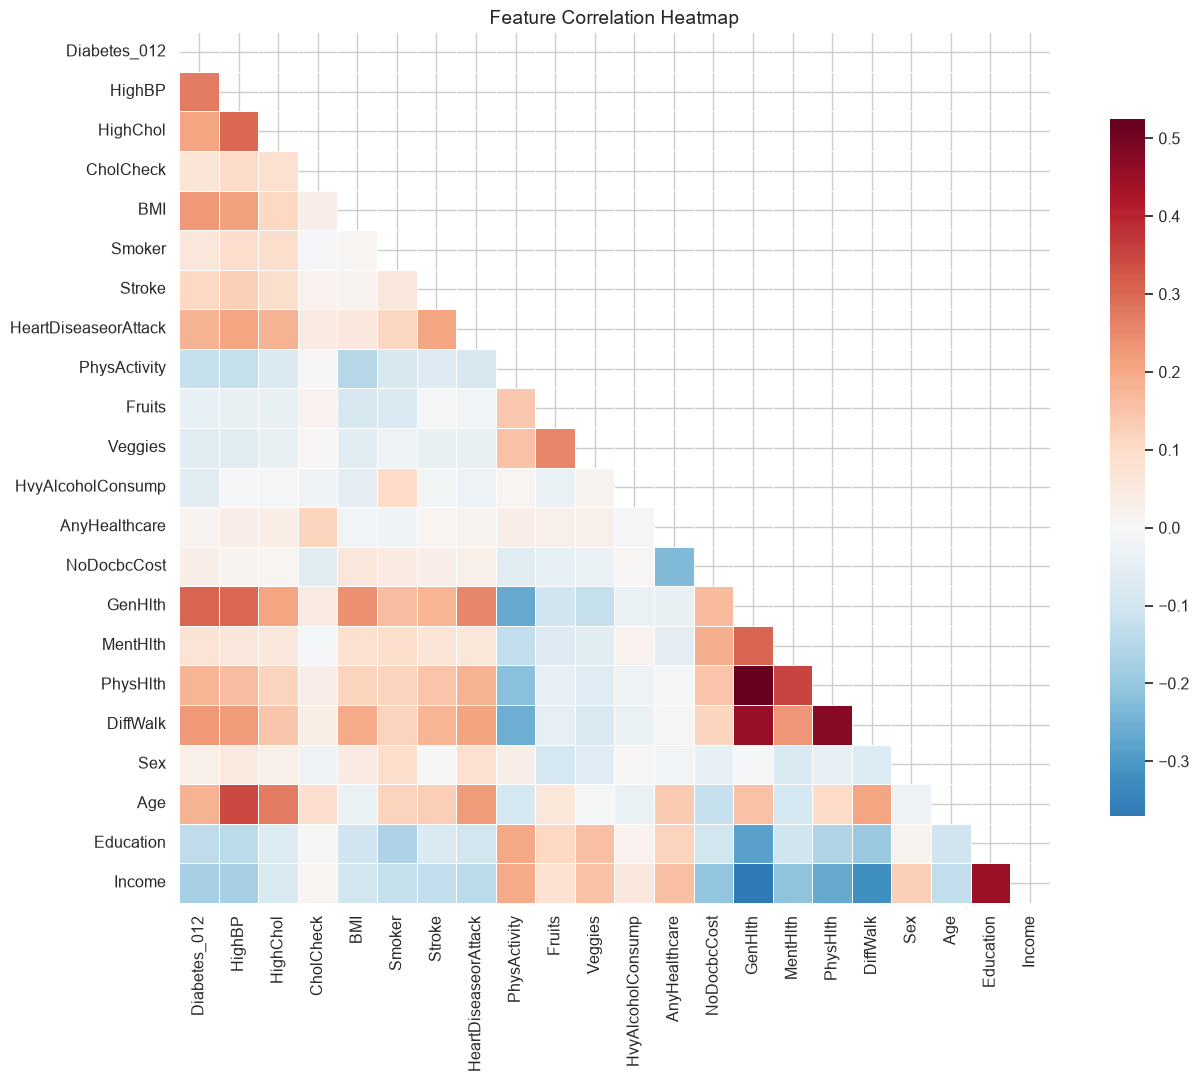


Pairs with |correlation| > 0.8:
Empty DataFrame
Columns: [Feature1, Feature2, Corr]
Index: []


In [5]:
# Drop the temporary label column for correlation
corr = df.drop(columns=["Diabetes_label"]).corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

# Flag high correlations
print("\nPairs with |correlation| > 0.8:")
high_corr = (
    corr.abs()
    .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
high_corr.columns = ["Feature1", "Feature2", "Corr"]
print(high_corr[high_corr["Corr"] > 0.8].sort_values("Corr", ascending=False))

In [6]:
print("PhysHlth vs GenHlth correlation:", df["PhysHlth"].corr(df["GenHlth"]).round(3))
print("MentHlth vs GenHlth correlation:", df["MentHlth"].corr(df["GenHlth"]).round(3))
print("BMI vs Age correlation:", df["BMI"].corr(df["Age"]).round(3))

PhysHlth vs GenHlth correlation: 0.524
MentHlth vs GenHlth correlation: 0.302
BMI vs Age correlation: -0.037


In [7]:
from scipy.stats import spearmanr

pairs = [
    ("PhysHlth", "GenHlth"),
    ("MentHlth", "GenHlth"),
    ("BMI", "Age")
]

for x, y in pairs:
    pearson = df[x].corr(df[y])
    spearman = spearmanr(df[x], df[y]).statistic
    
    print(f"\n{x} vs {y}")
    print(f"Pearson :  {pearson:.3f}")
    print(f"Spearman:  {spearman:.3f}")


PhysHlth vs GenHlth
Pearson :  0.524
Spearman:  0.452

MentHlth vs GenHlth
Pearson :  0.302
Spearman:  0.238

BMI vs Age
Pearson :  -0.037
Spearman:  -0.025


In [8]:
pd.crosstab(
    pd.cut(df["PhysHlth"], bins=[-1, 0, 5, 10, 20, 30]),
    df["GenHlth"],
    normalize="index"
).round(3)

GenHlth,1.0,2.0,3.0,4.0,5.0
PhysHlth,,,,,
"(-1, 0]",0.239,0.412,0.287,0.057,0.004
"(0, 5]",0.114,0.363,0.374,0.134,0.015
"(5, 10]",0.062,0.225,0.376,0.285,0.052
"(10, 20]",0.032,0.137,0.293,0.395,0.143
"(20, 30]",0.023,0.075,0.176,0.353,0.372


In [9]:
pd.crosstab(
    pd.cut(df["MentHlth"], bins=[-1, 0, 5, 10, 20, 30]),
    df["GenHlth"],
    normalize="index"
).round(3)

GenHlth,1.0,2.0,3.0,4.0,5.0
MentHlth,,,,,
"(-1, 0]",0.209,0.373,0.295,0.096,0.027
"(0, 5]",0.146,0.379,0.314,0.126,0.035
"(5, 10]",0.095,0.287,0.330,0.209,0.079
"(10, 20]",0.062,0.216,0.309,0.275,0.138
"(20, 30]",0.051,0.147,0.260,0.289,0.252


In [10]:
df.groupby("Age")["BMI"].agg(
    ["mean", "median", "std", "count"]
).round(2)

,mean,median,std,count
Age,,,,
1.0,26.09,25.0,6.63,5700
2.0,27.61,26.0,7.25,7598
3.0,28.43,27.0,7.76,11123
4.0,28.59,27.0,6.96,13823
5.0,28.91,27.0,7.17,16157
6.0,29.01,28.0,7.08,19819
7.0,28.94,28.0,6.90,26314
8.0,28.92,28.0,6.89,30832
9.0,28.75,28.0,6.54,33244


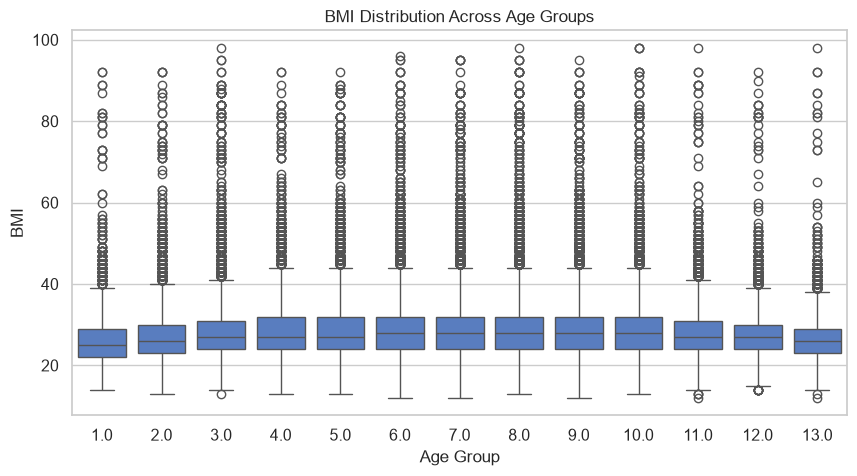

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Age",
    y="BMI"
)

plt.title("BMI Distribution Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("BMI")

plt.show()

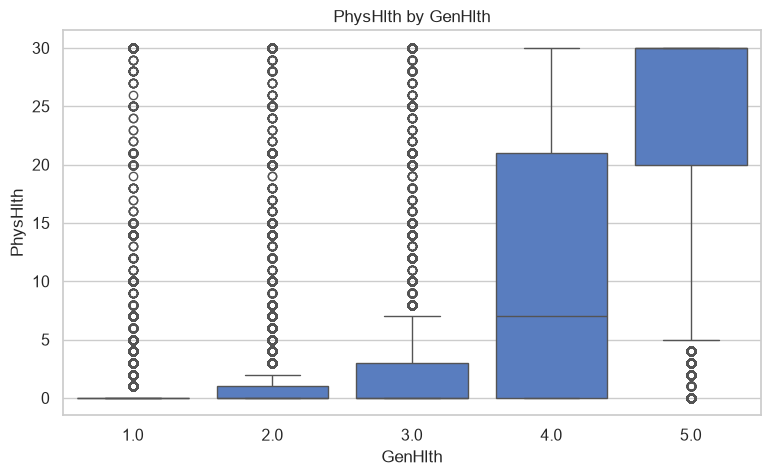

In [12]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    x=df["GenHlth"],
    y=df["PhysHlth"]
)

plt.title("PhysHlth by GenHlth")
plt.xlabel("GenHlth")
plt.ylabel("PhysHlth")

plt.show()

In [13]:
df.groupby("GenHlth")["PhysHlth"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)

,count,mean,median,std,min,max
GenHlth,,,,,,
1.0,45299,0.86,0.0,3.57,0.0,30.0
2.0,89084,1.53,0.0,4.64,0.0,30.0
3.0,75646,3.39,0.0,7.16,0.0,30.0
4.0,31570,11.39,7.0,11.77,0.0,30.0
5.0,12081,23.52,30.0,10.00,0.0,30.0
